# 📦 Preparación y balanceo del dataset

## Objetivo

Este notebook tiene como finalidad preparar el conjunto de datos que se utilizará posteriormente para entrenar el modelo de detección de desperfectos del pavimento mediante YOLOv8.

Las tareas realizadas en este proceso son:

- Revisión del dataset original.
- Limpieza de datos y eliminación de imágenes no válidas.
- Balanceo de las clases para reducir el desbalance del conjunto de entrenamiento.
- División del dataset en los conjuntos de:
  - **Train**
  - **Validation**
  - **Test**
- Generación del dataset final listo para el entrenamiento.

---

## Dataset de salida

Como resultado de este proceso se ha generado el archivo:

```text
dataset_limpio.zip
```

Este archivo contiene el dataset preparado en formato compatible con **YOLOv8**, incluyendo la estructura necesaria para su utilización en Google Colab y en el proceso de entrenamiento.

---

## Estructura del dataset

```text
dataset_limpio/
│
├── train/
│   ├── images/
│   └── labels/
│
├── valid/
│   ├── images/
│   └── labels/
│
├── test/
│   ├── images/
│   └── labels/
│
└── data.yaml
```

---

## Próximo paso

El siguiente notebook del proyecto será el encargado de entrenar distintos modelos YOLOv8 utilizando este dataset.

Cada integrante del equipo entrenará un modelo independiente (mínimo 50 épocas), comparando posteriormente las métricas obtenidas (**mAP50-95, mAP50, Precision, Recall y tiempo de inferencia**) para seleccionar el modelo con mejor rendimiento.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 1. Copiamos tu ZIP al disco rápido de Colab
!cp "/content/drive/MyDrive/Notebooks/train_balanced.zip" "/content/dataset_crudo.zip"

# 2. Lo descomprimimos en una carpeta temporal
!unzip -q "/content/dataset_crudo.zip" -d "/content/raw_dataset"

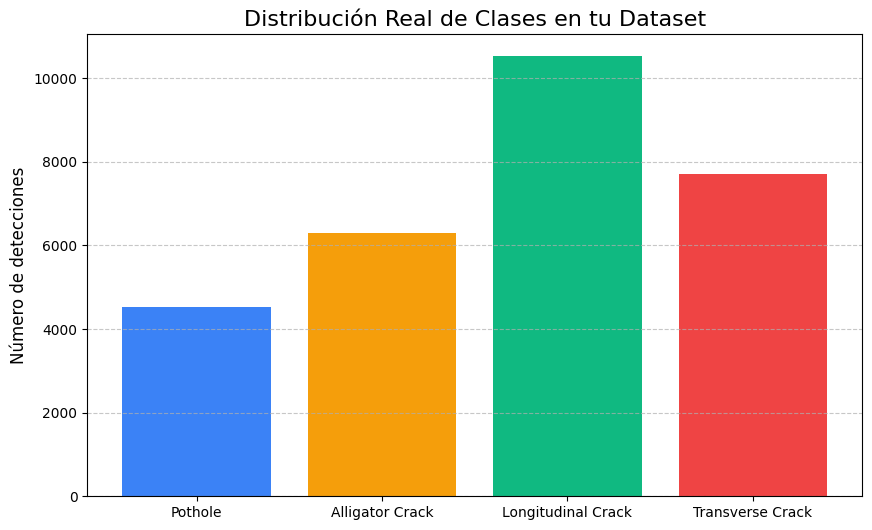


Conteo exacto:
- Pothole: 4536
- Alligator Crack: 6302
- Longitudinal Crack: 10525
- Transverse Crack: 7701


In [5]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# ¡RUTA CORREGIDA según tu imagen!
label_dir = Path('/content/raw_dataset/content/RoadGuardian-1/train_balanced/labels')

# Clases según vuestro briefing [cite: 17]
clases = {
    0: 'Alligator Crack',
    1: 'Longitudinal Crack',
    2: 'Pothole',
    3: 'Transverse Crack'
}
conteos = Counter()

# Leer todos los txt y contar
for txt_file in label_dir.glob('*.txt'):
    with open(txt_file, 'r') as f:
        for linea in f:
            try:
                # El primer número de cada línea es el ID de la clase
                class_id = int(linea.split()[0])
                conteos[class_id] += 1
            except:
                pass # Por si hay alguna línea en blanco o corrupta

# Preparar datos para el gráfico
nombres = [clases.get(i, f"Clase {i}") for i in conteos.keys()]
valores = list(conteos.values())

# Dibujar
if not valores:
    print("Aún no encuentra nada. Verifica que haciendo clic en la carpeta 'labels' de la izquierda haya archivos .txt dentro.")
else:
    plt.figure(figsize=(10, 6))
    plt.bar(nombres, valores, color=['#3b82f6', '#f59e0b', '#10b981', '#ef4444'])
    plt.title('Distribución Real de Clases en tu Dataset', fontsize=16)
    plt.ylabel('Número de detecciones', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print("\nConteo exacto:")
    for nombre, valor in zip(nombres, valores):
        print(f"- {nombre}: {valor}")

La Solución: El Filtro Inteligente (Script)Vamos a aplicar un algoritmo de selección que lea foto por foto y decida si la guarda basándose en unos límites estrictos. Aplicaremos los límites de 3.674 para Pothole y 5.000 para el resto de grietas.  

In [6]:
import os
import shutil
import random
import yaml
from pathlib import Path

# 1. Rutas exactas
source_images = Path('/content/raw_dataset/content/RoadGuardian-1/train_balanced/images')
source_labels = Path('/content/raw_dataset/content/RoadGuardian-1/train_balanced/labels')
base_dir = Path('/content/datasets')

# Limpiar cualquier dataset anterior para empezar frescos
if base_dir.exists():
    shutil.rmtree(base_dir)

# 2. Límites objetivo
target_counts = {
    0: 5000,  # Alligator Crack
    1: 5000,  # Longitudinal Crack
    2: 3674,  # Pothole
    3: 5000   # Transverse Crack
}
current_counts = {0: 0, 1: 0, 2: 0, 3: 0}
kept_pairs = []

# 3. Recopilar y mezclar todos los pares
all_pairs = []
for ext in ('*.jpg', '*.jpeg', '*.png', '*.JPG'):
    for img_path in source_images.glob(ext):
        lbl_path = source_labels / f"{img_path.stem}.txt"
        if lbl_path.exists():
            all_pairs.append((img_path, lbl_path))

random.seed(42)
random.shuffle(all_pairs)

# 4. Algoritmo de filtrado inteligente
print("Procesando y balanceando imágenes...")
for img, lbl in all_pairs:
    classes_in_img = set()
    with open(lbl, 'r') as f:
        for line in f:
            try:
                classes_in_img.add(int(line.split()[0]))
            except:
                pass

    # ¿Podemos añadir esta imagen sin pasarnos del límite en ninguna de sus clases?
    can_add = True
    for c in classes_in_img:
        if c in current_counts and current_counts[c] >= target_counts[c]:
            can_add = False
            break

    if can_add and classes_in_img:
        kept_pairs.append((img, lbl))
        for c in classes_in_img:
            current_counts[c] += 1

print(f"\nTotal de imágenes seleccionadas para entrenar: {len(kept_pairs)}")
print(f"Cajas finales aproximadas: {current_counts}")

# 5. Crear carpetas de YOLO y mover archivos
splits = ['train', 'val', 'test']
for split in splits:
    (base_dir / 'images' / split).mkdir(parents=True, exist_ok=True)
    (base_dir / 'labels' / split).mkdir(parents=True, exist_ok=True)

total = len(kept_pairs)
train_end = int(total * 0.70)
val_end = int(total * 0.85)

splits_data = {
    'train': kept_pairs[:train_end],
    'val': kept_pairs[train_end:val_end],
    'test': kept_pairs[val_end:]
}

print("\nMoviendo archivos a las carpetas de entrenamiento...")
for split_name, files in splits_data.items():
    for img, lbl in files:
        shutil.copy(img, base_dir / 'images' / split_name / img.name)
        shutil.copy(lbl, base_dir / 'labels' / split_name / lbl.name)
    print(f"- {split_name.upper()}: {len(files)} imágenes.")

# 6. Crear data.yaml
yaml_content = {
    'train': '/content/datasets/images/train',
    'val': '/content/datasets/images/val',
    'test': '/content/datasets/images/test',
    'nc': 4,
    'names': ['Alligator Crack', 'Longitudinal Crack', 'Pothole', 'Transverse Crack']
}

yaml_path = base_dir / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, sort_keys=False)

print("\n¡Dataset balanceado y estructurado con éxito!")

Procesando y balanceando imágenes...

Total de imágenes seleccionadas para entrenar: 10882
Cajas finales aproximadas: {0: 5000, 1: 5000, 2: 2560, 3: 5000}

Moviendo archivos a las carpetas de entrenamiento...
- TRAIN: 7617 imágenes.
- VAL: 1632 imágenes.
- TEST: 1633 imágenes.

¡Dataset balanceado y estructurado con éxito!
